In [4]:
# -*- coding: utf-8 -*-
"""info_internship.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/15AuFyx6E4E5-FAwgHTWTrT1BRJGpFKom
"""

!pip install numpy pandas matplotlib opencv-python pillow torch torchvision pycocotools

import os

file_path = "/content/instances_train2017.json"
print("File exists:", os.path.exists(file_path))
print("File size (MB):", os.path.getsize(file_path) / (1024*1024))

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
import requests


annotation_file = "/content/annotations/instances_train2017.json"
coco = COCO(annotation_file)

person_cat_id = coco.getCatIds(catNms=['person'])
img_ids = coco.getImgIds(catIds=person_cat_id)
img_info = coco.loadImgs(img_ids[0])[0]

print("Selected Image:", img_info['file_name'])

img_url = f"http://images.cocodataset.org/train2017/{img_info['file_name']}"
response = requests.get(img_url)

image_path = f"/content/{img_info['file_name']}"
with open(image_path, "wb") as f:
    f.write(response.content)

print("Image downloaded successfully!")

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

ann_ids = coco.getAnnIds(
    imgIds=img_info['id'],
    catIds=person_cat_id,
    iscrowd=None
)

anns = coco.loadAnns(ann_ids)
mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

for ann in anns:
    mask += coco.annToMask(ann)
mask = np.clip(mask, 0, 1)
plt.figure(figsize=(6,6))
plt.imshow(mask, cmap='gray')
plt.title("Generated Person Mask")
plt.axis("off")
plt.show()

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
import requests

annotation_file = "/content/annotations/instances_train2017.json"
coco = COCO(annotation_file)

target_categories = ['person', 'apple', 'banana', 'orange', 'umbrella']
cat_ids = coco.getCatIds(catNms=target_categories)

print("Selected Categories:", target_categories)
print("Category IDs:", cat_ids)
img_ids = coco.getImgIds(catIds=cat_ids)
img_info = coco.loadImgs(img_ids[0])[0]
print("Selected Image:", img_info['file_name'])

img_url = f"http://images.cocodataset.org/train2017/{img_info['file_name']}"

response = requests.get(img_url)
image_path = f"/content/{img_info['file_name']}"

with open(image_path, "wb") as f:
    f.write(response.content)

print("Image downloaded successfully!")

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

ann_ids = coco.getAnnIds(
    imgIds=img_info['id'],
    catIds=cat_ids,
    iscrowd=None
)

anns = coco.loadAnns(ann_ids)
mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

for ann in anns:
    mask += coco.annToMask(ann)

mask = np.clip(mask, 0, 1)
plt.figure(figsize=(6,6))
plt.imshow(mask, cmap='gray')
plt.title("People + Fruits + Umbrella Mask")
plt.axis("off")
plt.show()

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
import requests

annotation_file = "/content/annotations/instances_train2017.json"
coco = COCO(annotation_file)
target_categories = ['person', 'apple', 'banana', 'orange', 'umbrella']

cat_ids = coco.getCatIds(catNms=target_categories)
print("Selected Categories:", target_categories)

img_ids = coco.getImgIds(catIds=cat_ids)
img_info = coco.loadImgs(img_ids[0])[0]
print("Selected Image:", img_info['file_name'])
img_url = f"http://images.cocodataset.org/train2017/{img_info['file_name']}"

response = requests.get(img_url)
image_path = f"/content/{img_info['file_name']}"

with open(image_path, "wb") as f:
    f.write(response.content)
print("Image downloaded successfully!")

image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

plt.figure(figsize=(6,6))
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")
plt.show()

ann_ids = coco.getAnnIds(
    imgIds=img_info['id'],
    catIds=cat_ids,
    iscrowd=None
)

anns = coco.loadAnns(ann_ids)
colored_mask = np.zeros_like(image_np)

colors = {
    coco.getCatIds(catNms=['person'])[0]: [255, 0, 0],
    coco.getCatIds(catNms=['apple'])[0]: [0, 255, 0],
    coco.getCatIds(catNms=['banana'])[0]: [0, 0, 255],
    coco.getCatIds(catNms=['orange'])[0]: [255, 255, 0],
    coco.getCatIds(catNms=['umbrella'])[0]: [255, 0, 255]
}

for ann in anns:
    cat_id = ann['category_id']
    mask_binary = coco.annToMask(ann)
    colored_mask[mask_binary == 1] = colors[cat_id]


overlay = image_np.copy()
overlay = (1 - alpha) * overlay + alpha * colored_mask
overlay = overlay.astype(np.uint8)


plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title("Overlay Segmentation (People + Fruits + Umbrella)")
plt.axis("off")
plt.show()

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, random_split
import torchvision.transforms as transforms
from pycocotools.coco import COCO
import requests

if not os.path.exists("/content/annotations_trainval2017.zip"):
    print("Downloading annotations_trainval2017.zip...")
    os.system("wget -c http://images.cocodataset.org/annotations/annotations_trainval2017.zip")


if not os.path.exists("/content/annotations/instances_train2017.json"):
    print("Unzipping annotations_trainval2017.zip...")
    os.system("unzip -q -o /content/annotations_trainval2017.zip -d /content/")


annotation_file = "/content/annotations/instances_train2017.json"
image_folder = "/content/"

print(f"Verifying annotation file path: {annotation_file}")
if not os.path.exists(annotation_file):
    print(f"ERROR: Annotation file still not found at {annotation_file} after attempted download and unzip.")
    print(f"Contents of /content/: {os.listdir('/content/')}")
    if os.path.exists('/content/annotations'):
        print(f"Contents of /content/annotations/: {os.listdir('/content/annotations')}")
    raise FileNotFoundError(f"Annotation file not found: {annotation_file}")

coco = COCO(annotation_file)
print("COCO loaded successfully!")

image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor()
])

class CocoSegmentationDataset(Dataset):
    def __init__(self, coco, image_folder, category_name='person',
                 image_transform=None, mask_transform=None):

        self.coco = coco
        self.image_folder = image_folder
        self.category_name = category_name
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        self.cat_ids = self.coco.getCatIds(catNms=[category_name])
        self.img_ids = self.coco.getImgIds(catIds=self.cat_ids)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, index):
        img_id = self.img_ids[index]
        img_info = self.coco.loadImgs(img_id)[0]

        img_path = os.path.join(self.image_folder, img_info['file_name'])

        if not os.path.exists(img_path):
            img_url = f"http://images.cocodataset.org/train2017/{img_info['file_name']}"
            response = requests.get(img_url)
            with open(img_path, "wb") as f:
                f.write(response.content)

        image = Image.open(img_path).convert("RGB")
        image = np.array(image)
        ann_ids = self.coco.getAnnIds(
            imgIds=img_info['id'],
            catIds=self.cat_ids,
            iscrowd=None
        )
        anns = self.coco.loadAnns(ann_ids)

        mask = np.zeros((img_info['height'], img_info['width']))
        for ann in anns:
            mask += self.coco.annToMask(ann)

        mask = np.clip(mask, 0, 1).astype(np.uint8)
        if self.image_transform:
            image = self.image_transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)

        return image, mask
dataset = CocoSegmentationDataset(
    coco,
    image_folder,
    category_name='person',
    image_transform=image_transform,
    mask_transform=mask_transform
)

print("Total samples:", len(dataset))
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
image, mask = dataset[0]

print("Image shape:", image.shape)  # (3, 256, 256)
print("Mask shape:", mask.shape)    # (1, 256, 256)
print("Mask unique values:", torch.unique(mask))
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Resized Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Resized Mask")
plt.axis("off")

plt.show()

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, random_split
import torchvision.transforms as transforms
from pycocotools.coco import COCO
import requests
import random

if not os.path.exists("/content/annotations_trainval2017.zip"):
    print("Downloading annotations...")
    os.system("wget -c http://images.cocodataset.org/annotations/annotations_trainval2017.zip")

if not os.path.exists("/content/annotations/instances_train2017.json"):
    print("Unzipping annotations...")
    os.system("unzip -q -o /content/annotations_trainval2017.zip -d /content/")

annotation_file = "/content/annotations/instances_train2017.json"
image_folder = "/content/"

coco = COCO(annotation_file)
print("COCO loaded successfully!")

image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor()
])

class CocoSegmentationDataset(Dataset):
    def __init__(self, coco, image_folder, category_name='person',
                 image_transform=None, mask_transform=None):

        self.coco = coco
        self.image_folder = image_folder
        self.category_name = category_name
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        self.cat_ids = self.coco.getCatIds(catNms=[category_name])
        self.img_ids = self.coco.getImgIds(catIds=self.cat_ids)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, index):
        img_id = self.img_ids[index]
        img_info = self.coco.loadImgs(img_id)[0]

        img_path = os.path.join(self.image_folder, img_info['file_name'])

        if not os.path.exists(img_path):
            img_url = f"http://images.cocodataset.org/train2017/{img_info['file_name']}"
            response = requests.get(img_url)
            with open(img_path, "wb") as f:
                f.write(response.content)

        image = Image.open(img_path).convert("RGB")
        image = np.array(image)

        ann_ids = self.coco.getAnnIds(
            imgIds=img_info['id'],
            catIds=self.cat_ids,
            iscrowd=None
        )
        anns = self.coco.loadAnns(ann_ids)

        mask = np.zeros((img_info['height'], img_info['width']))
        for ann in anns:
            mask += self.coco.annToMask(ann)

        mask = np.clip(mask, 0, 1).astype(np.uint8)

        if self.image_transform:
            image = self.image_transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)

        return image, mask

dataset = CocoSegmentationDataset(
    coco,
    image_folder,
    category_name='person',
    image_transform=image_transform,
    mask_transform=mask_transform
)

print("Total samples:", len(dataset))

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

num_samples = 6
indices = random.sample(range(len(dataset)), num_samples)

plt.figure(figsize=(12, num_samples * 3))

for i, idx in enumerate(indices):
    image, mask = dataset[idx]

    plt.subplot(num_samples, 2, 2*i + 1)
    plt.imshow(image.permute(1,2,0))
    plt.title(f"Image {i+1}")
    plt.axis("off")

    plt.subplot(num_samples, 2, 2*i + 2)
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.title(f"Mask {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

image, mask = dataset[0]
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask unique values:", torch.unique(mask))



File exists: False


FileNotFoundError: [Errno 2] No such file or directory: '/content/instances_train2017.json'

Annotation file exists: True
loading annotations into memory...
Done (t=25.10s)
creating index...
index created!
COCO Loaded Successfully
Total images with PERSON: 64115
Sample Image: 000000262145.jpg


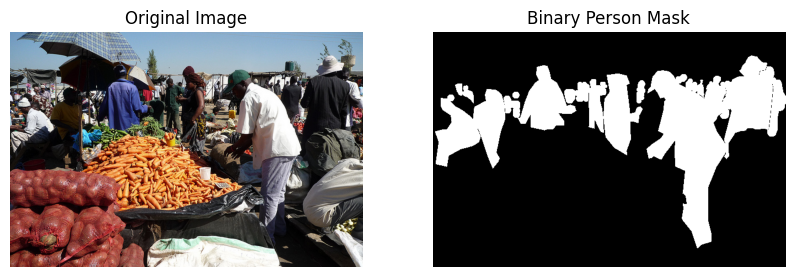

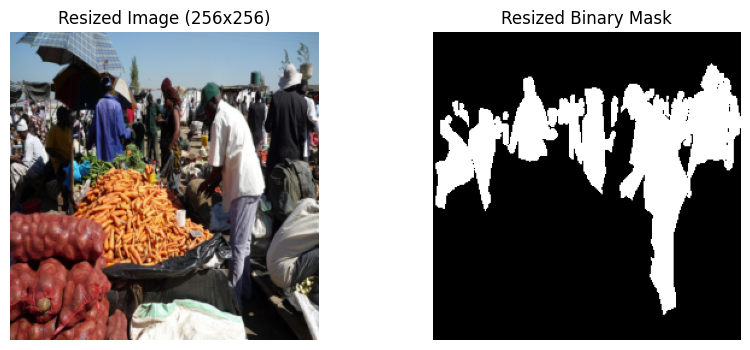

In [6]:
# ================================
# MILESTONE 1 : DATASET + PREPROCESSING
# ================================

# --------- INSTALL REQUIRED LIBRARIES ----------
!pip install -q pycocotools opencv-python matplotlib pillow torch torchvision

# --------- IMPORTS ----------
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from pycocotools.coco import COCO
import torchvision.transforms as transforms
from torch.utils.data import Dataset

# --------- DOWNLOAD COCO ANNOTATIONS ----------
if not os.path.exists("/content/annotations_trainval2017.zip"):
    print("Downloading COCO annotations...")
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip

if not os.path.exists("/content/annotations/instances_train2017.json"):
    print("Unzipping annotations...")
    !unzip -q annotations_trainval2017.zip -d /content/

# --------- VERIFY FILE ----------
annotation_file = "/content/annotations/instances_train2017.json"
print("Annotation file exists:", os.path.exists(annotation_file))

# --------- LOAD COCO ----------
coco = COCO(annotation_file)
print("COCO Loaded Successfully")

# --------- SELECT CATEGORY (MAIN SUBJECT = PERSON) ----------
category_name = "person"
cat_ids = coco.getCatIds(catNms=[category_name])
img_ids = coco.getImgIds(catIds=cat_ids)

print("Total images with PERSON:", len(img_ids))

# --------- PICK ONE IMAGE ----------
img_info = coco.loadImgs(img_ids[0])[0]
print("Sample Image:", img_info["file_name"])

# --------- DOWNLOAD IMAGE ----------
img_url = f"http://images.cocodataset.org/train2017/{img_info['file_name']}"
img_path = f"/content/{img_info['file_name']}"

if not os.path.exists(img_path):
    response = requests.get(img_url)
    with open(img_path, "wb") as f:
        f.write(response.content)

# --------- LOAD IMAGE ----------
image = Image.open(img_path).convert("RGB")
image_np = np.array(image)

# --------- LOAD MASK ----------
ann_ids = coco.getAnnIds(imgIds=img_info["id"], catIds=cat_ids)
anns = coco.loadAnns(ann_ids)

mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)
for ann in anns:
    mask += coco.annToMask(ann)

mask = np.clip(mask, 0, 1)

# --------- VISUALIZE ORIGINAL + MASK ----------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Binary Person Mask")
plt.axis("off")

plt.show()

# --------- PREPROCESSING PIPELINE ----------
image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256,256), interpolation=Image.NEAREST),
    transforms.ToTensor()
])

image_resized = image_transform(image_np)
mask_resized = mask_transform(mask)

# --------- SHOW PREPROCESSED OUTPUT ----------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image_resized.permute(1,2,0))
plt.title("Resized Image (256x256)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask_resized.squeeze(), cmap="gray")
plt.title("Resized Binary Mask")
plt.axis("off")

plt.show()


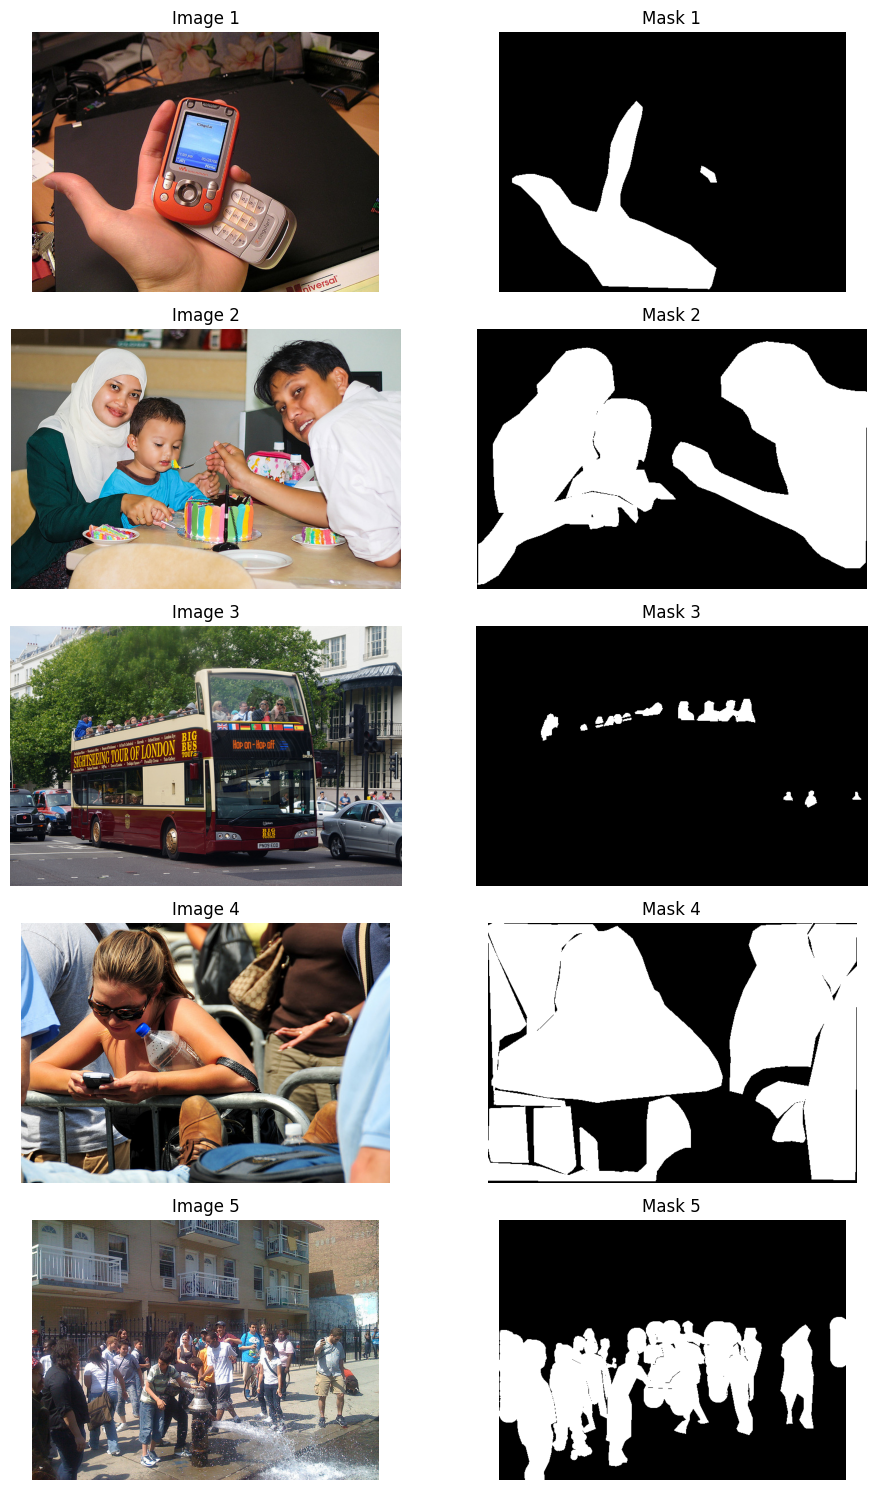

In [7]:
import random

num_samples = 5
random_ids = random.sample(img_ids, num_samples)

plt.figure(figsize=(10, num_samples * 3))

for i, img_id in enumerate(random_ids):

    img_info = coco.loadImgs(img_id)[0]
    img_url = f"http://images.cocodataset.org/train2017/{img_info['file_name']}"
    img_path = f"/content/{img_info['file_name']}"

    # Download if not exists
    if not os.path.exists(img_path):
        response = requests.get(img_url)
        with open(img_path, "wb") as f:
            f.write(response.content)

    image = Image.open(img_path).convert("RGB")
    image_np = np.array(image)

    ann_ids = coco.getAnnIds(imgIds=img_info["id"], catIds=cat_ids)
    anns = coco.loadAnns(ann_ids)

    mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)
    for ann in anns:
        mask += coco.annToMask(ann)

    mask = np.clip(mask, 0, 1)

    # Show image
    plt.subplot(num_samples, 2, 2*i + 1)
    plt.imshow(image_np)
    plt.title(f"Image {i+1}")
    plt.axis("off")

    # Show mask
    plt.subplot(num_samples, 2, 2*i + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()